# Post Test - Efficiency Calculation

In [ ]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd() / "EPump Sizer"))
from defineImpeller import impellerClass
from CoolProp.CoolProp import PropsSI
import math
# inputs (all in m)
d_2 = .0493
e_rs = .002
d_D = .008
d_1 = .015
eta_V = .95 # estimated volumetric efficiency


1141.8833369482168


In [ ]:
# find nominal efficiency values
n = 25000
H = 171
Q = .002
rho = PropsSI("D","T",90,'P|liquid',(p_outlet),'Oxygen')
visc_1 = PropsSI('V','T',90,'P|liquid',(p_outlet),'Oxygen')/PropsSI("D","T",90,'P|liquid',(p_outlet),'Oxygen')

# axial force calculations

# Radial force calculations

# Bearing power loss calcs

# Seal power loss Calcs

# disk friction losses

# report values

In [ ]:
# find efficiency values for a given test
fluid = "Water"
p_outlet = 300 # psi
Q = .002 # m^3/s


p_tank = p_outlet * 6894.75729 # convert from psi to Pa
if fluid == "Water":
    rho = 1000
    visc_1 = PropsSI('V','T',300,'P|liquid',(p_outlet),'Water')/PropsSI("D","T",300,'P|liquid',(p_outlet),'Water')
elif fluid == "Lox":
    rho = PropsSI('D','T',90,'P|liquid',(p_outlet),'Oxygen') 
    visc_1 = PropsSI('V','T',90,'P|liquid',(p_outlet),'Oxygen')/PropsSI("D","T",90,'P|liquid',(p_outlet),'Oxygen')

# Imbalance Tolerance for Balancing or Remachining
There are two methods I can think of to select the necessary G rating for the shaft, both of which come from the load that will be generated at a specific level, and then taking the more precise of both of them. 

the first is by treating the impeller as a cantilevered beam fixed at the upper bearing, and then adding the maximum imbalance force at the max length to the anticipated radial force at full RPM. 


In [ ]:
import numpy as np
#shaft dimensions from CAD
gap = .0001 # m
l = .003256 # m
D = 2*.00755 # m
E = 200e9 # Pa
m = .16249 # kg
# impeller dimensions from CAD
d2 = .02465*2 # m
b2 = .005 #m
H = 181.7131
# other inputs
I = np.pi*D**4/64 # m^4
n = 25000 # rpm
omega = n*2*np.pi/60 # rad/s
# Hydro force
rho = 1000 # kg/m^3
kr = .35
krdyn = .12
f_hydro = (kr+krdyn)*rho*9.81*H*d2*b2
print("Hydro Force (N): ", f_hydro)
# backsolve for radial force
f_imb = gap*3*E*I/(l**3) - f_hydro
print("Imbalance Force (N): ", f_imb)
U = f_imb/(omega**2) * 10**6 # g*mm 
print("Unbalance: ", U, " g*mm")
Grating = U*omega/(1000*m)
print("G - Rating: ", Grating)

Hydro Force (N):  206.52376147690498
Imbalance Force (N):  4435632.217723899
Unbalance:  647169.8493626973  g*mm
G - Rating:  10427021.377636895


The second method is to go off the max load rating for the bearings. 

In [ ]:
l = .003256 # m, gap between upper bearing and impeller
l2 = .020 # m, distance between upper and lower bearing
d2 = .02465*2 # m
b2 = .005 #m
H = 181.7131
# other inputs
n = 25000 # rpm
# allowable bearing load
f_bear = 3750
f_tot_allowed = f_bear/(1+(l/l2))
# hydro load
rho = 1000 # kg/m^3
kr = .35
krdyn = .12
f_hydro = (kr+krdyn)*rho*9.81*H*d2*b2 # n
print("Hydro Force (N): ", f_hydro)
#solve for reaction at top bearing
f_imb = f_tot_allowed - f_hydro # n
print("Allowable Imbalance Force (N): ", f_imb)
U = f_imb/(omega**2) * 10**6 # g*mm 
print("Unbalance: ", U, " g*mm")
Grating = U*omega/(1000*m)
print("G - Rating: ", Grating)

Hydro Force (N):  206.52376147690498
Allowable Imbalance Force (N):  3018.4504387294933
Unbalance:  440.39947855364073  g*mm
G - Rating:  7095.5944287284


If neither of these require more precision than G40, we will instead stipulate G40 as that is the recommendation in ISO standards, according to the following image

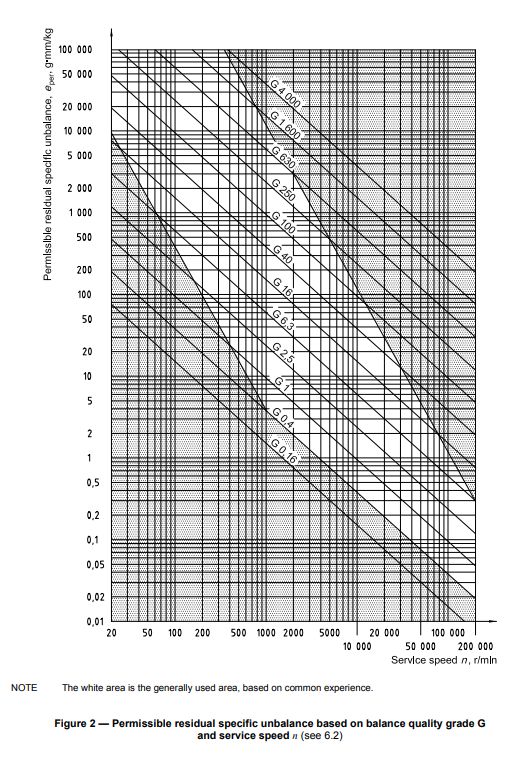

In [ ]:
from IPython.display import Image, display
display(Image(filename="C:\\Users\\sakno\\OneDrive\\Documents\\GitHub\\YJSP Turbo Team\\EPump\\EPump Sizer\\Pump Guide Images\\grangerecs.png"))

Therefore, according to this math finding a minimum G-rating well above G40, we will stipulate G40 as the rating.

# RPM Selection - Reynold's number
We first attempt to select RPM using Reynold's number

In [40]:
from CoolProp.CoolProp import PropsSI
visc_water = PropsSI("VISCOSITY", "T", 293.15, "P", 400*6895, "Water") / PropsSI("D", "T", 293.15, "P", 400*6895, "Water")
print("Water Viscosity", visc_water)
visc_lox = PropsSI("VISCOSITY", "T", 90, "P|liquid", 400*6895, "Oxygen") / PropsSI("D", "T", 90, "P|liquid", 400*6895, "Oxygen")
print("LOX Viscosity", visc_lox)
n_lox = 25000
n_water = n_lox * (visc_water/visc_lox)
print("Waterflow RPM",n_water)

Water Viscosity 1.0013744224304395e-06
LOX Viscosity 1.7502430847762634e-07
Waterflow RPM 143033.62074966388


It can be seen clearly that we can therefore not use reynold's number to find a test RPM. Therefore, we elect to go with the RPM labelled above for the tests, namely 2k for proof and 7.5k for 

This is done with the same method as the pump guide, with the following modifications made to how each mode is carried out. It should be run after the test, based on pressure values across the impeller and bearing, flowrate, temp, and RPM values found. 
#### Impeller Mods
1. 

#### Bearing Mods
1. Layout changed
2. Working fluid changed
3. Shaft dimensions changed

#### Seal Mods
1. Completely different method using friction value from PDR

In [39]:
RPM = 1#selected before test
fluid = "water"
H = # from measurement
Q = # from measurement
Qseal = # from measurement
dpBearings = # from measurement
t_amb = # from measurement
d_2 = # mm

## =============== impeller section =============== #

## =============== bearing section =============== #

## =============== seal section =============== #

print("power (w) = ", power)
print("hydraulic efficiency = ", eta_H)
print("overall efficiency = ", eta_o)

SyntaxError: invalid syntax (1888186694.py, line 3)